## All Feature Lead ChurnRate to Rising

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

df = pd.read_csv('../../../data/processed/telco_customer_churn_clean.csv')

### Contract Feature

In [4]:
pd.crosstab(df["Contract"], df["Churn"], normalize="index")

Churn,No,Yes
Contract,,
Month-to-month,0.572903,0.427097
One year,0.887305,0.112695
Two year,0.971681,0.028319


<Axes: xlabel='Contract', ylabel='count'>

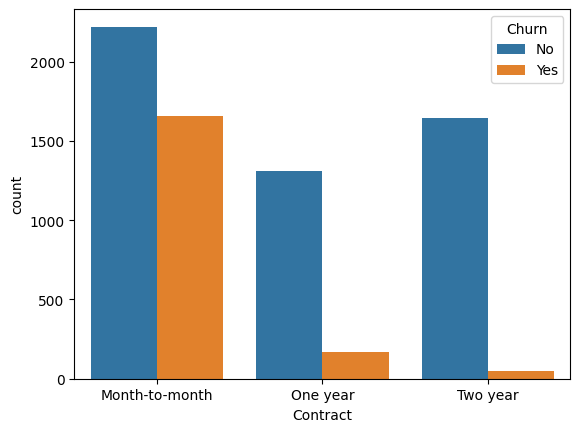

In [5]:
sns.countplot(x="Contract", hue="Churn", data=df)

<Axes: xlabel='Contract', ylabel='Churn'>

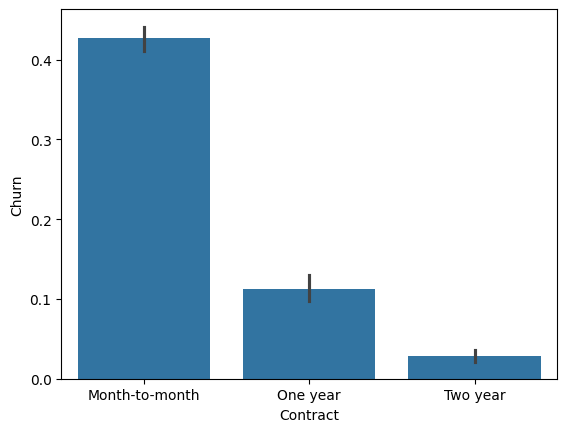

In [8]:
sns.barplot(
    data=df,
    x="Contract",
    y=(df["Churn"]=="Yes").astype(int)
)

#### question? if Contract = Month to Mont combine with Charge Higher how much it effect Churn Rate.

In [6]:
pd.crosstab(
    [df["Contract"], df["ChargeGroup"]],
    df["Churn"],
    normalize="index"
)

Churn                                 No       Yes
Contract       ChargeGroup                        
Month-to-month (18.249, 35.5]   0.749654  0.250346
               (35.5, 70.35]    0.643823  0.356177
               (70.35, 89.85]   0.467178  0.532822
               (89.85, 118.75]  0.478161  0.521839
One year       (18.249, 35.5]   0.969543  0.030457
               (35.5, 70.35]    0.913747  0.086253
               (70.35, 89.85]   0.889313  0.110687
               (89.85, 118.75]  0.791480  0.208520
Two year       (18.249, 35.5]   0.992248  0.007752
               (35.5, 70.35]    0.975524  0.024476
               (70.35, 89.85]   0.984472  0.015528
               (89.85, 118.75]  0.929864  0.070136

In [11]:
table = pd.crosstab(df["Contract"], df["Churn"])
chi2, p, dof, expected = chi2_contingency(table)

print(p)

5.863038300673391e-258


Contract มีความสัมพันธ์กับ churn

Insight 2 :

    - Month-to-month contract มี churn สูงสุด

    - MonthlyCharges สูง = churn สูง

    - Month-to-month + ราคาแพง = churn สูงมาก (มากกว่า 50%)

Customers with month-to-month contracts and high monthly charges show the highest churn rates, exceeding 50%.
To reduce churn, the company should consider offering discounts or incentives to encourage customers to switch to longer-term contracts such as one-year or two-year plans.
Additionally, loyalty programs and retention strategies may help increase customer tenure and reduce churn risk.